<a href="https://colab.research.google.com/github/Cristina-as/e-commerce-business-intelligence/blob/main/Conhe%C3%A7a_o_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bike Sharing Demand Prediction using Machine Learning
Nesse projeto de Ciência de Dados e Machine Learning foi desenvolvido uma previsão de demanda de bicicletas compartilhadas utilizando dados climáticos e temporais.

## Importação de bibliotecas

In [34]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Configuração visual
sns.set_style('whitegrid')



# Upload do Dataset

In [35]:
from google.colab import files

uploaded = files.upload()

Saving day.csv to day (5).csv


In [36]:
from google.colab import files

uploaded = files.upload()

Saving hour.csv to hour (4).csv


## Carregando os Dados

In [37]:
# Dataset diário
day_df = pd.read_csv('day.csv')

# Dataset por hora
hour_df = pd.read_csv('hour.csv')

## Vizualização de Dados

In [38]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344,0.364,0.806,0.160,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363,0.354,0.696,0.249,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196,0.189,0.437,0.248,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200,0.212,0.590,0.160,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.227,0.229,0.437,0.187,82,1518,1600


In [39]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.240,0.288,0.810,0.000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.220,0.273,0.800,0.000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.220,0.273,0.800,0.000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.240,0.288,0.750,0.000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.240,0.288,0.750,0.000,0,1,1


## Informações Gerais

In [40]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [41]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000,731.000,731.000,731.000,731.000,731.000,731.000,731.000,731.000,731.000,731.000,731.000,731.000,731.000,731.000
mean,366.000,2.497,0.501,6.520,0.029,2.997,0.684,1.395,0.495,0.474,0.628,0.190,848.176,3656.172,4504.349
std,211.166,1.111,0.500,3.452,0.167,2.005,0.465,0.545,0.183,0.163,0.142,0.077,686.622,1560.256,1937.211
min,1.000,1.000,0.000,1.000,0.000,0.000,0.000,1.000,0.059,0.079,0.000,0.022,2.000,20.000,22.000
25%,183.500,2.000,0.000,4.000,0.000,1.000,0.000,1.000,0.337,0.338,0.520,0.135,315.500,2497.000,3152.000
50%,366.000,3.000,1.000,7.000,0.000,3.000,1.000,1.000,0.498,0.487,0.627,0.181,713.000,3662.000,4548.000
75%,548.500,3.000,1.000,10.000,0.000,5.000,1.000,2.000,0.655,0.609,0.730,0.233,1096.000,4776.500,5956.000
max,731.000,4.000,1.000,12.000,1.000,6.000,1.000,3.000,0.862,0.841,0.973,0.507,3410.000,6946.000,8714.000


## Análise Exploratória de Dados
Foi realizado análises estatísticas e visuais para identificar padrões de comportamento da demanda ao longo do tempo.

In [43]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual
plt.rcParams['figure.figsize'] = (12,6)
sns.set_style('whitegrid')

In [44]:
from google.colab import files

uploaded = files.upload()

Saving hour.csv to hour (5).csv


## Carregando o Dataset

In [45]:
df = pd.read_csv('hour.csv')

In [46]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.240,0.288,0.810,0.000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.220,0.273,0.800,0.000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.220,0.273,0.800,0.000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.240,0.288,0.750,0.000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.240,0.288,0.750,0.000,0,1,1


## Dimensão do Dataset, tipos de Dados e Estatísticas Descritivas

In [47]:
print(f'Linhas: {df.shape[0]}')
print(f'Colunas: {df.shape[1]}')

Linhas: 17379
Colunas: 17


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [49]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000
mean,8690.000,2.502,0.503,6.538,11.547,0.029,3.004,0.683,1.425,0.497,0.476,0.627,0.190,35.676,153.787,189.463
std,5017.029,1.107,0.500,3.439,6.914,0.167,2.006,0.465,0.639,0.193,0.172,0.193,0.122,49.305,151.357,181.388
min,1.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.020,0.000,0.000,0.000,0.000,0.000,1.000
25%,4345.500,2.000,0.000,4.000,6.000,0.000,1.000,0.000,1.000,0.340,0.333,0.480,0.104,4.000,34.000,40.000
50%,8690.000,3.000,1.000,7.000,12.000,0.000,3.000,1.000,1.000,0.500,0.485,0.630,0.194,17.000,115.000,142.000
75%,13034.500,3.000,1.000,10.000,18.000,0.000,5.000,1.000,2.000,0.660,0.621,0.780,0.254,48.000,220.000,281.000
max,17379.000,4.000,1.000,12.000,23.000,1.000,6.000,1.000,4.000,1.000,1.000,1.000,0.851,367.000,886.000,977.000


## Verificação de Valores Nulos

In [50]:
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


## Análise da Variável Target
Quantidade Total de Bicicletas Alugadas





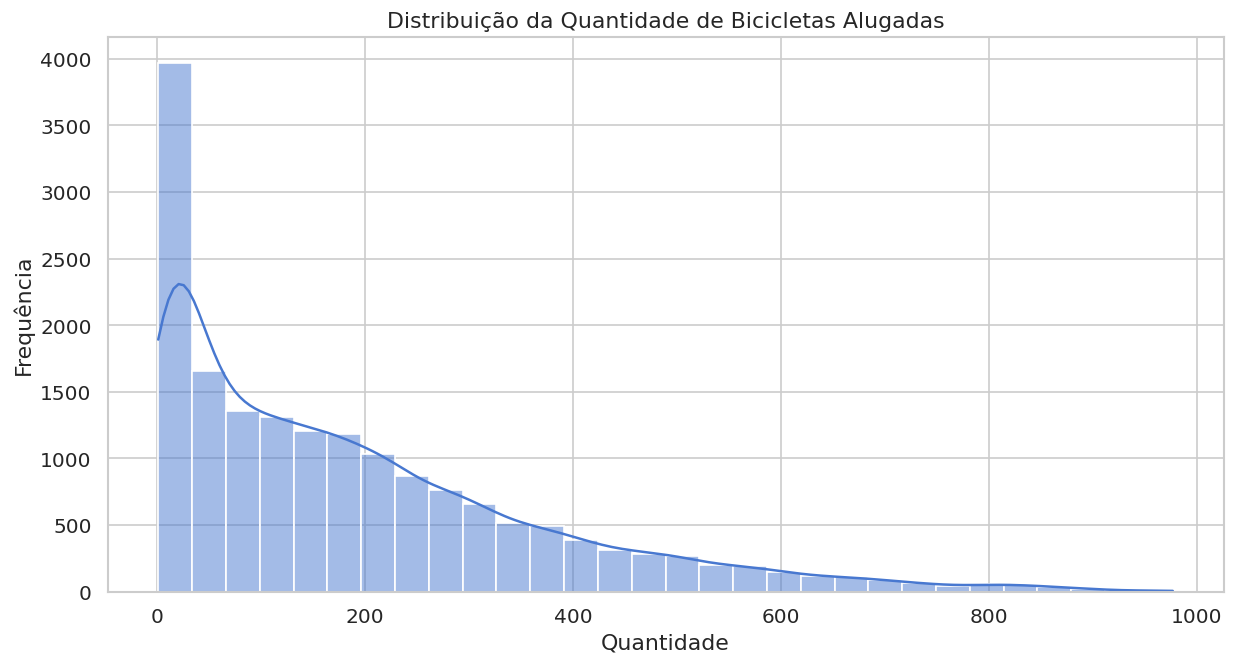

In [51]:
# Distribuição da Demanda

sns.histplot(df['cnt'], bins=30, kde=True)

plt.title('Distribuição da Quantidade de Bicicletas Alugadas')
plt.xlabel('Quantidade')
plt.ylabel('Frequência')

plt.show()

sns.histplot(df['cnt'], bins=30, kde=True)

plt.title('Distribuição da Quantidade de Bicicletas Alugadas')
plt.xlabel('Quantidade')
plt.ylabel('Frequência')

plt.show()

A distribuição da demanda apresenta assimetria positiva, indicando períodos de alta concentração de alugueis em determinados horários.

## Correlação

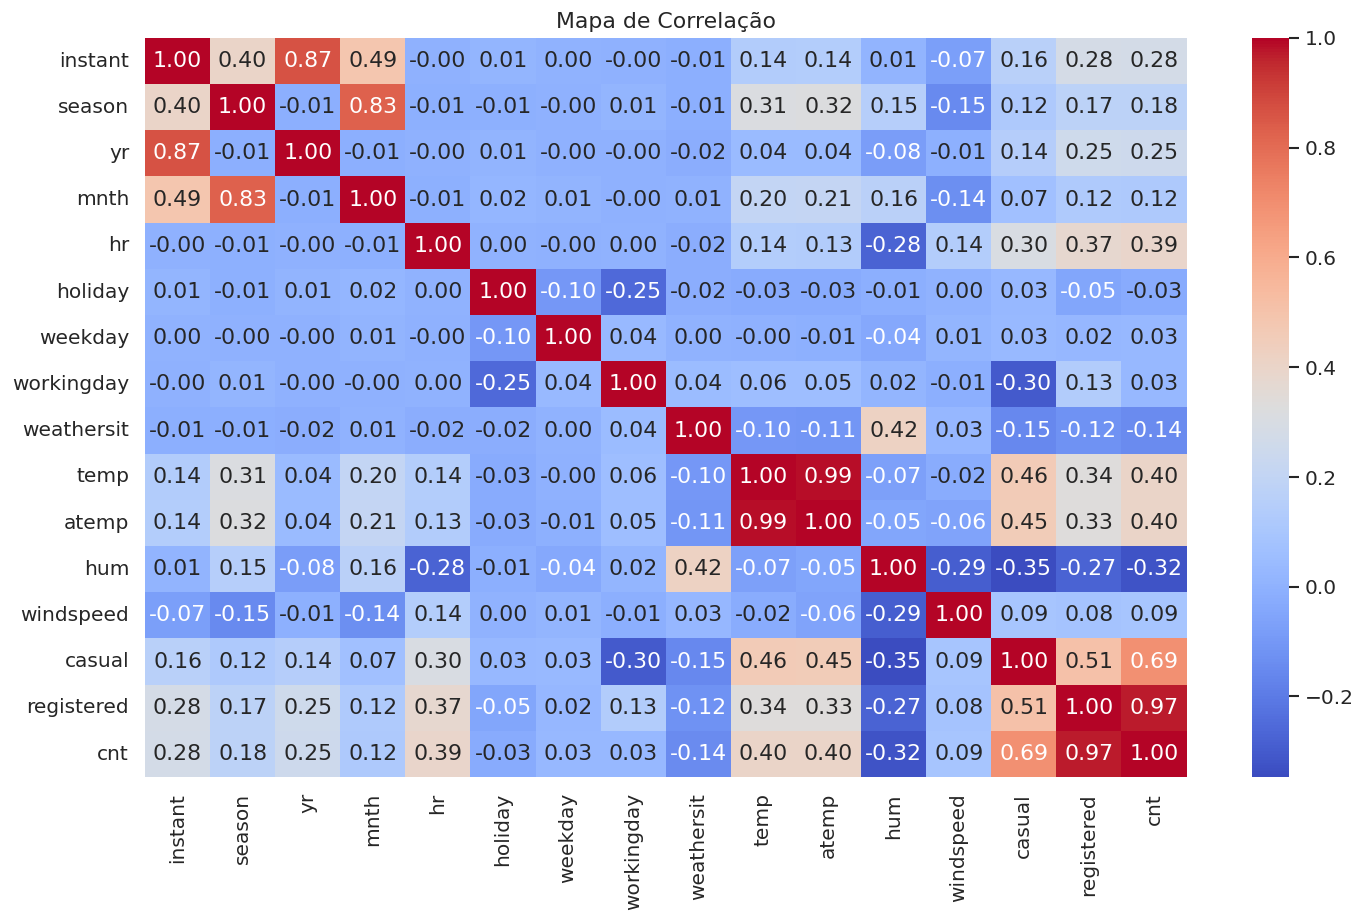

In [52]:
# Heatmap

plt.figure(figsize=(14,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Mapa de Correlação')
plt.show()

Insights Esperados

"temp" possui forte correlação positiva com "cnt"                                                                        
"hum" possui correlação negativa                                              
"registered" possui altíssima correlação com "cnt"

## Demanda por Hora

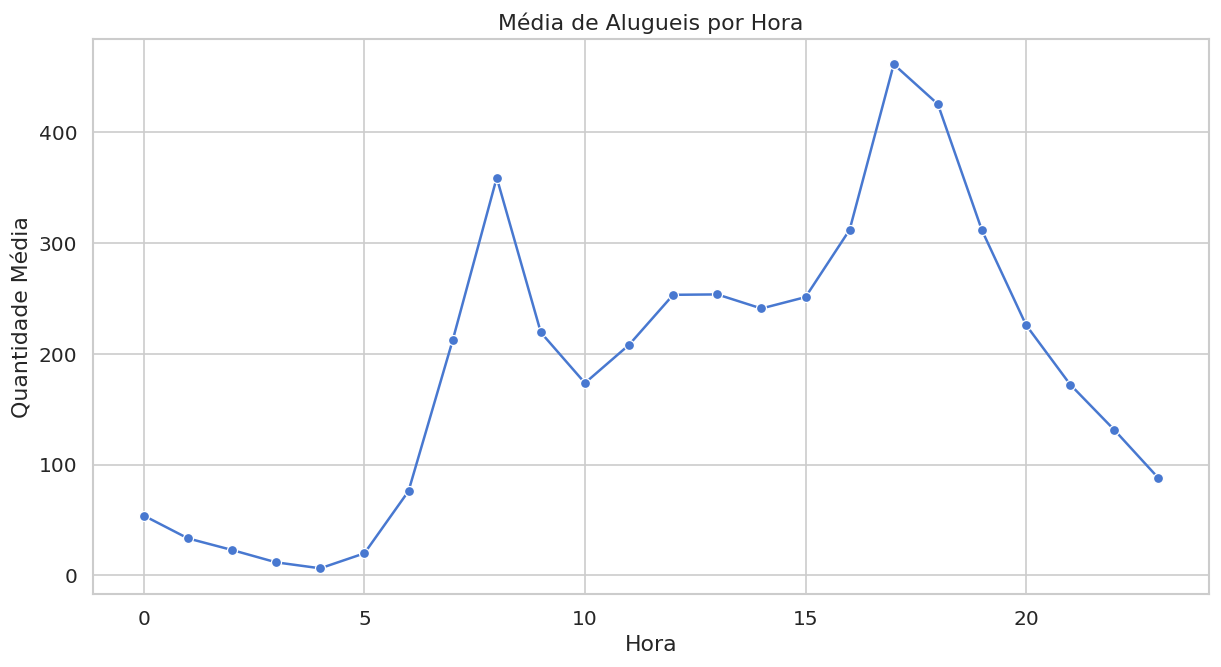

In [53]:
hourly_rentals = df.groupby('hr')['cnt'].mean()

sns.lineplot(
    x=hourly_rentals.index,
    y=hourly_rentals.values,
    marker='o'
)

plt.title('Média de Alugueis por Hora')
plt.xlabel('Hora')
plt.ylabel('Quantidade Média')

plt.show()

Os maiores picos de demanda ocorrem em horários de deslocamento urbano, principalmente pela manhã e final do dia.

## Demanda por Estação

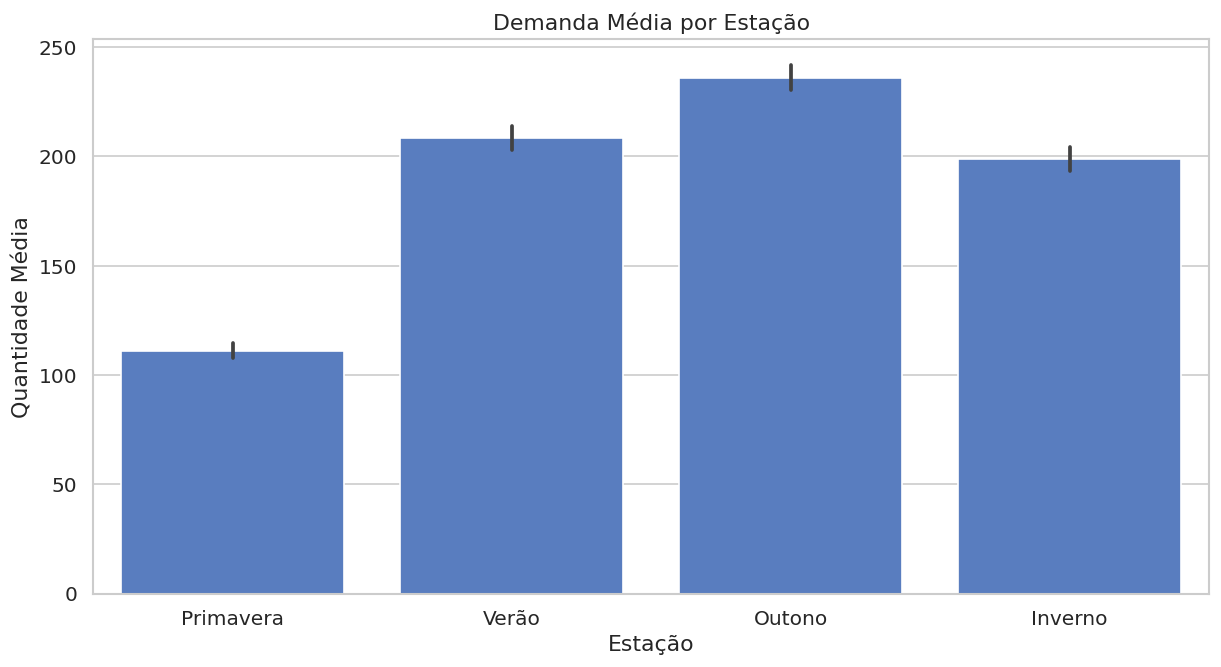

In [54]:
season_labels = {
    1: 'Primavera',
    2: 'Verão',
    3: 'Outono',
    4: 'Inverno'
}

df['season_name'] = df['season'].map(season_labels)

sns.barplot(
    data=df,
    x='season_name',
    y='cnt',
    estimator=np.mean
)

plt.title('Demanda Média por Estação')
plt.xlabel('Estação')
plt.ylabel('Quantidade Média')

plt.show()

Estações mais quentes apresentam maior volume de alugueis.

## Demanda por Clima

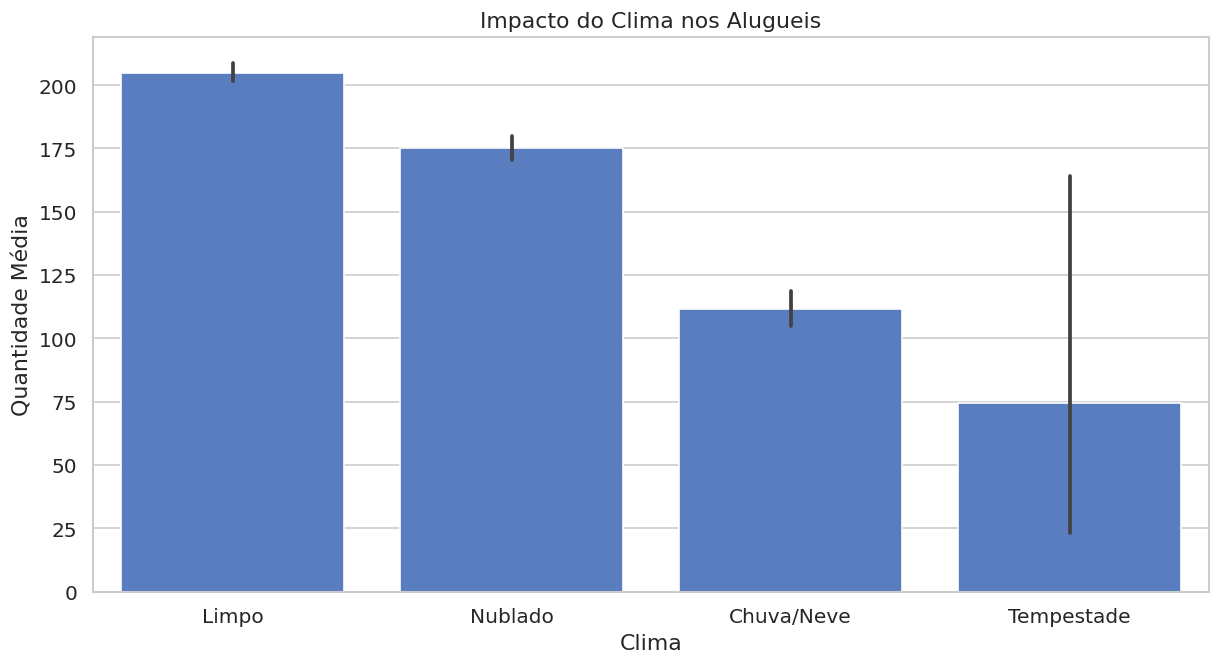

In [55]:
# Impacto climático

weather_labels = {
    1: 'Limpo',
    2: 'Nublado',
    3: 'Chuva/Neve',
    4: 'Tempestade'
}

df['weather_name'] = df['weathersit'].map(weather_labels)

sns.barplot(
    data=df,
    x='weather_name',
    y='cnt',
    estimator=np.mean
)

plt.title('Impacto do Clima nos Alugueis')
plt.xlabel('Clima')
plt.ylabel('Quantidade Média')

plt.show()

Condições climáticas severas reduzem significativamente a demanda.

## Demanda por Dia da Semana

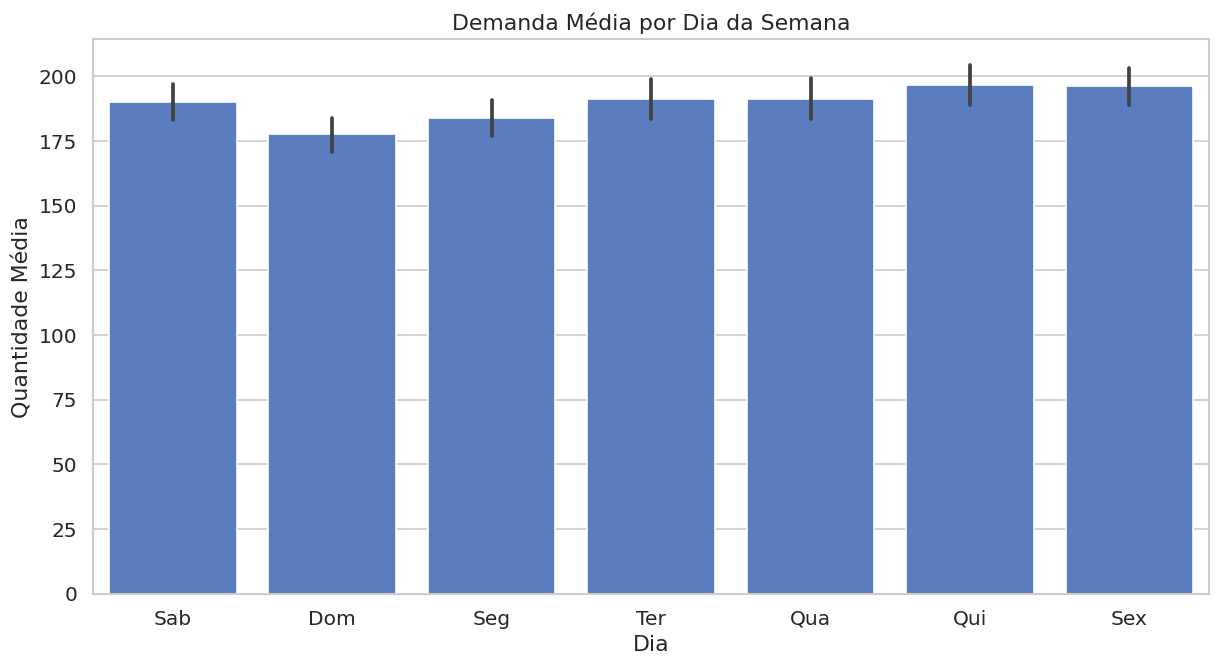

In [56]:
weekday_labels = {
    0: 'Dom',
    1: 'Seg',
    2: 'Ter',
    3: 'Qua',
    4: 'Qui',
    5: 'Sex',
    6: 'Sab'
}

df['weekday_name'] = df['weekday'].map(weekday_labels)

sns.barplot(
    data=df,
    x='weekday_name',
    y='cnt',
    estimator=np.mean
)

plt.title('Demanda Média por Dia da Semana')
plt.xlabel('Dia')
plt.ylabel('Quantidade Média')

plt.show()

Dias úteis apresentam maior uso por usuários registrados devido a deslocamentos urbanos.

## Temperatura x Demanda

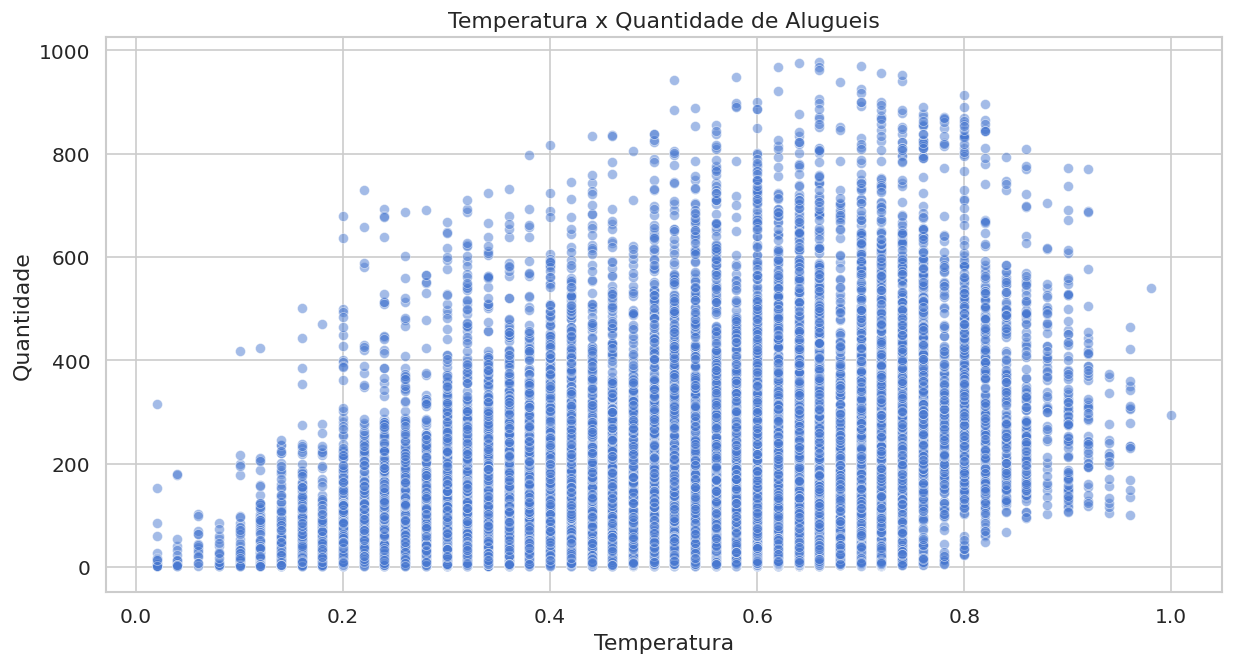

In [57]:
sns.scatterplot(
    data=df,
    x='temp',
    y='cnt',
    alpha=0.5
)

plt.title('Temperatura x Quantidade de Alugueis')
plt.xlabel('Temperatura')
plt.ylabel('Quantidade')

plt.show()

Existe relação positiva entre temperatura e quantidade de bicicletas alugadas.

## Boxplot da Demanda

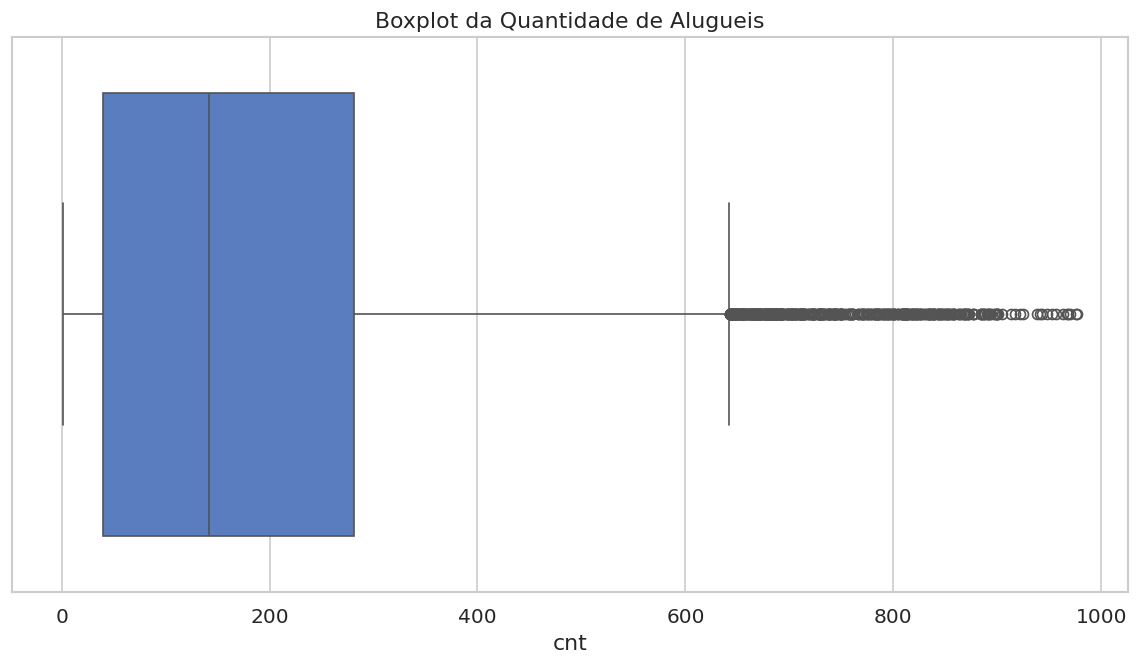

In [58]:
# Outliers

sns.boxplot(x=df['cnt'])

plt.title('Boxplot da Quantidade de Alugueis')

plt.show()

Existem períodos de alta demanda considerados outliers, principalmente em horários de pico.

## Série Temporal

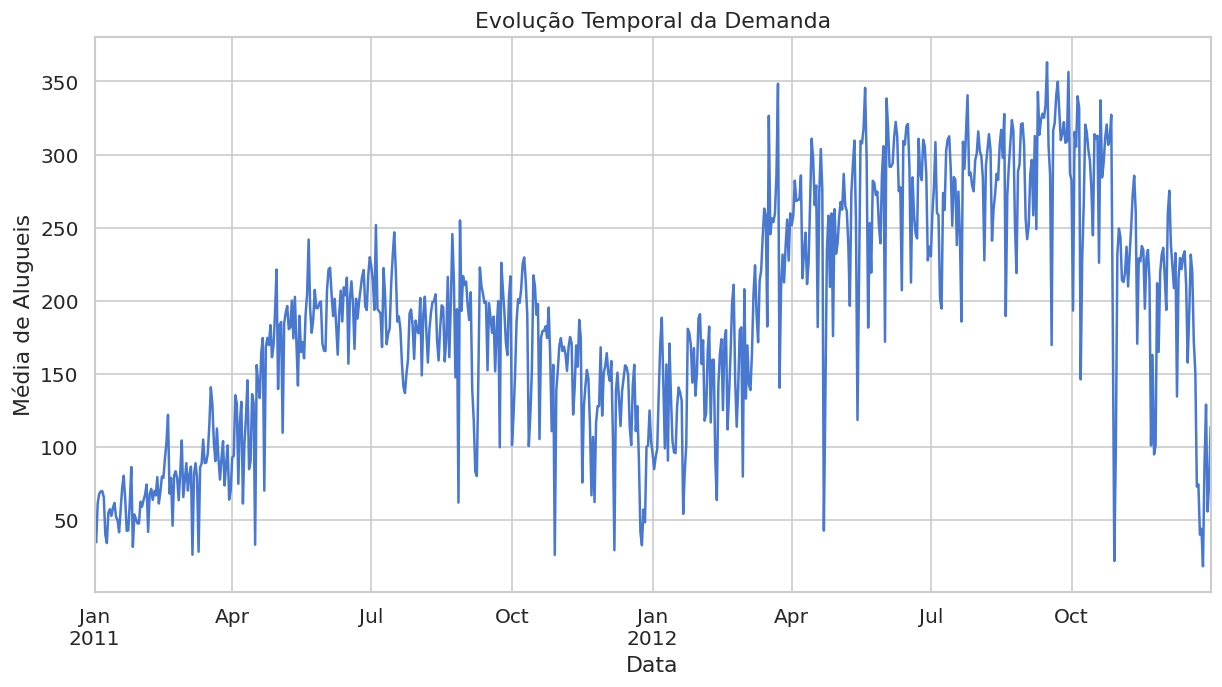

In [59]:
# Tendência Temporal

df['dteday'] = pd.to_datetime(df['dteday'])

daily_demand = df.groupby('dteday')['cnt'].mean()

daily_demand.plot()

plt.title('Evolução Temporal da Demanda')
plt.xlabel('Data')
plt.ylabel('Média de Alugueis')

plt.show()

O comportamento da demanda apresenta sazonalidade e tendência temporal ao longo dos anos.

Conclusões:                                                                  
Temperatura influencia positivamente os alugueis                             
Climas ruins reduzem drasticamente a demanda                                 
Horários de pico concentram maior utilização                              
Dias úteis possuem maior volume de usuários registrados                 
Existe forte sazonalidade no comportamento da demanda

## Machine Learning
 Modelos preditivos para estimar a quantidade de bicicletas alugadas.

In [60]:
# Features
X = df[[
    'season',
    'yr',
    'mnth',
    'hr',
    'holiday',
    'weekday',
    'workingday',
    'weathersit',
    'temp',
    'atemp',
    'hum',
    'windspeed'
]]

# Target
y = df['cnt']

## Divisão Treino e Teste

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (13903, 12)
Teste: (3476, 12)


## Baiselabel Model

In [63]:
# Linear Regression

from sklearn.linear_model import LinearRegression

# Criar modelo
lr_model = LinearRegression()

# Treinar
lr_model.fit(X_train, y_train)

print("Modelo treinado!")

Modelo treinado!


## Predições

In [64]:
# Previsões
lr_predictions = lr_model.predict(X_test)

## Avaliação do Modelo

In [65]:
# Métricas

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# MAE
mae = mean_absolute_error(y_test, lr_predictions)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

# R²
r2 = r2_score(y_test, lr_predictions)

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.2f}')

MAE: 104.80
RMSE: 139.21
R²: 0.39


## Random Forest

In [68]:
from sklearn.ensemble import RandomForestRegressor

# Modelo
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Treinar
rf_model.fit(X_train, y_train)

print("Random Forest treinado!")


Random Forest treinado!


## Predição Random Forest

In [69]:
rf_predictions = rf_model.predict(X_test)

## Avaliação Random Forest

In [70]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(y_test, rf_predictions)

print(f'MAE: {rf_mae:.2f}')
print(f'RMSE: {rf_rmse:.2f}')
print(f'R²: {rf_r2:.2f}')

MAE: 24.90
RMSE: 42.07
R²: 0.94


O modelo Random Forest apresentou excelente desempenho preditivo, demonstrando forte capacidade de prever a demanda de bicicletas compartilhadas.

## Comparando os Modelos

In [71]:
results = pd.DataFrame({
    'Modelo': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, rf_mae],
    'RMSE': [rmse, rf_rmse],
    'R2': [r2, rf_r2]
})

results

,Modelo,MAE,RMSE,R2
0,Linear Regression,104.803,139.211,0.388
1,Random Forest,24.903,42.069,0.944


## Feature Importance

In [72]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
3,hr,0.612
8,temp,0.119
1,yr,0.081
6,workingday,0.058
10,hum,0.027
9,atemp,0.022
0,season,0.022
7,weathersit,0.018
2,mnth,0.017
5,weekday,0.012


## Vizualização de Features

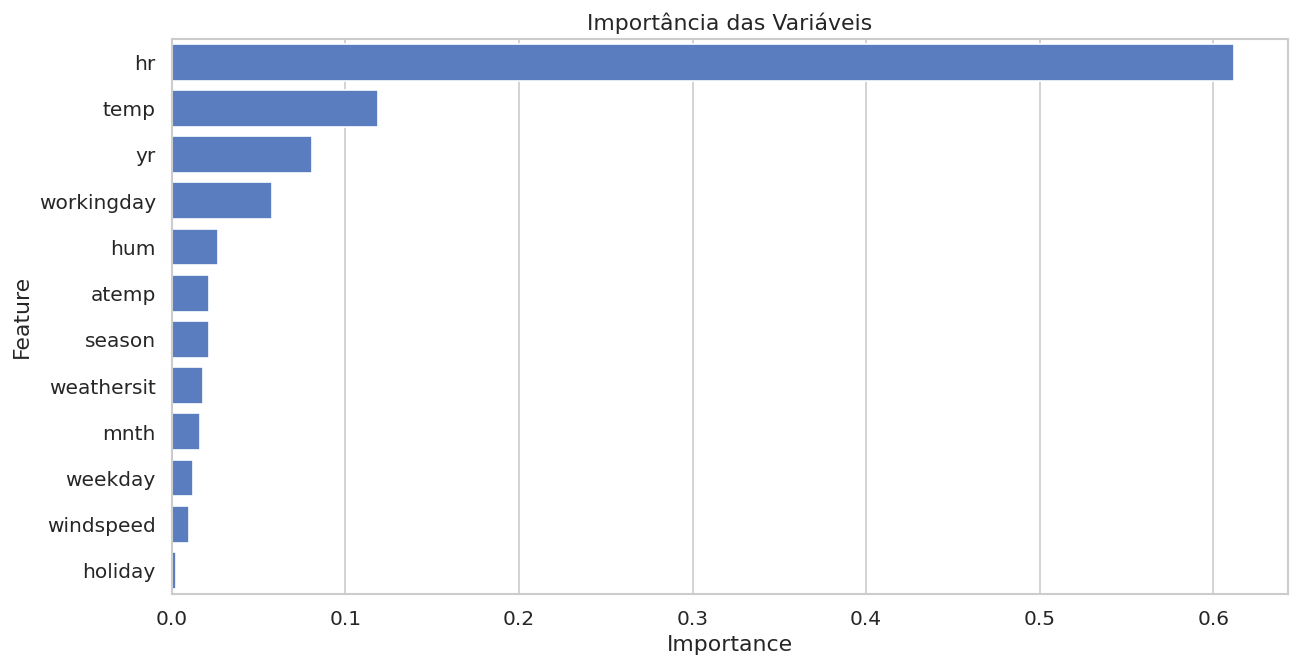

In [73]:
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Importância das Variáveis')

plt.show()

## Predições vs Valores Reais

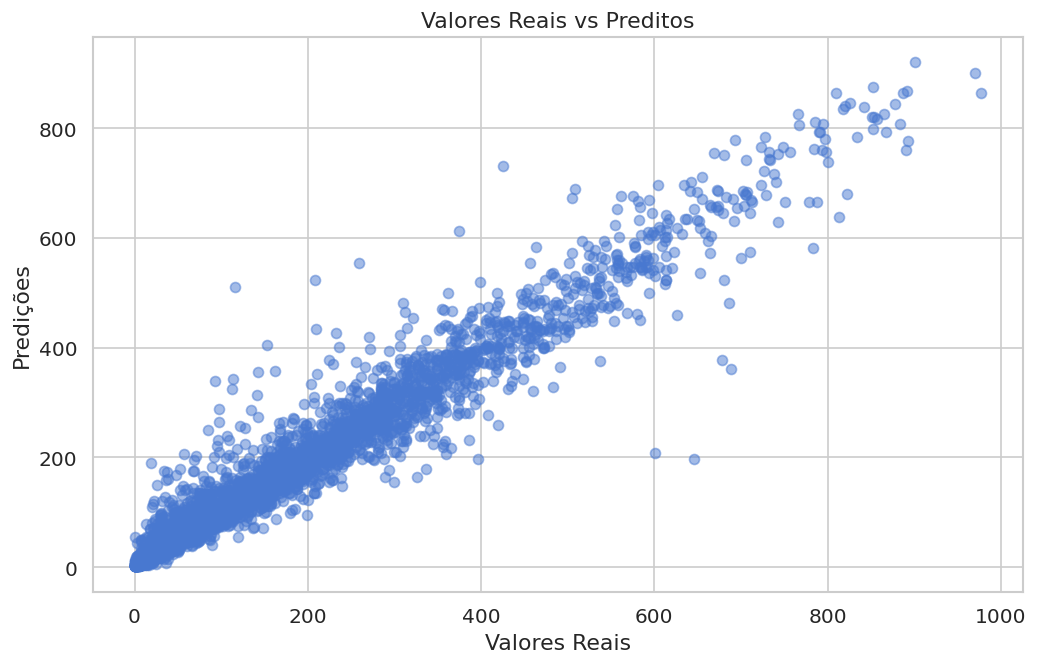

In [74]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.5
)

plt.xlabel('Valores Reais')
plt.ylabel('Predições')

plt.title('Valores Reais vs Preditos')

plt.show()